In [8]:
# imports & paths

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
from sklearn.inspection import permutation_importance

ROOT_DIR = Path("..").resolve()
DATA_DIR = ROOT_DIR / "data"

TRAIN_TX_PATH = DATA_DIR / "atm_transactions_train.csv"
TEST_TX_PATH  = DATA_DIR / "atm_transactions_test.csv"  # adjust if needed
CAL_PATH      = DATA_DIR / "calendar.csv"
META_PATH     = DATA_DIR / "atm_metadata.csv"
REGION_PATH   = DATA_DIR / "atm_region_lookup.csv"
REPL_PATH     = DATA_DIR / "cash_replenishment.csv"

MODELS_DIR  = ROOT_DIR / "models"
OUTPUT_DIR  = ROOT_DIR / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print("Root:", ROOT_DIR)
print("Train exists:", TRAIN_TX_PATH.exists())
print("Test exists:", TEST_TX_PATH.exists())
print("Models dir:", MODELS_DIR.exists())

Root: /Users/khaledalrashidi/Desktop/Projects/gulf_bank_datathon
Train exists: True
Test exists: True
Models dir: True


In [10]:
# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

# Cell 2: data loading & feature engineering helpers (no imports from train.py)

def load_clean_transactions(train_path: Path, test_path: Path):
    """Load and clean transaction data for train and test."""
    # --- Train ---
    train = pd.read_csv(train_path)

    train = train.rename(columns={
        "dt": "dt",
        "atm_id": "atm_id",
        "total_withdrawn_amount_kwd": "withdrawn_kwd",
        "total_withdraw_txn_count": "withdraw_count",
    })

    train["dt"] = pd.to_datetime(train["dt"])
    train = (
        train[["dt", "atm_id", "withdrawn_kwd", "withdraw_count"]]
        .drop_duplicates()
        .groupby(["atm_id", "dt"], as_index=False)[["withdrawn_kwd", "withdraw_count"]]
        .sum()
    )
    train["is_train"] = 1

    # --- Test ---
    test = pd.read_csv(test_path)
    test["dt"] = pd.to_datetime(test["dt"])
    test = test[["dt", "atm_id"]].copy()
    test["withdrawn_kwd"] = np.nan
    test["withdraw_count"] = np.nan
    test["is_train"] = 0

    return train, test


def load_calendar(path: Path) -> pd.DataFrame:
    cal = pd.read_csv(path)
    cal["dt"] = pd.to_datetime(cal["dt"])

    for col in ["is_weekend", "is_public_holiday",
                "is_salary_disbursement", "is_ramadan"]:
        if col in cal.columns:
            cal[col] = cal[col].astype(int)

    return cal


def load_atm_metadata(meta_path: Path, region_path: Path) -> pd.DataFrame:
    meta = pd.read_csv(meta_path)

    meta = meta.rename(columns={
        "region": "atm_region_meta",
        "location_type": "location_type_meta",
    })

    if "installed_date" in meta.columns:
        meta["installed_date"] = pd.to_datetime(meta["installed_date"])
    if "decommissioned_date" in meta.columns:
        meta["decommissioned_date"] = pd.to_datetime(meta["decommissioned_date"])

    reg = pd.read_csv(region_path)
    reg = reg.rename(columns={
        "region": "region_lookup",
        "location_type": "location_type_lookup",
    })

    meta = meta.merge(reg, on="atm_id", how="left")

    if "atm_region_meta" in meta.columns and "region_lookup" in meta.columns:
        meta["region_mismatch_flag"] = (
            meta["atm_region_meta"] != meta["region_lookup"]
        ).astype(int)

    return meta


def load_replenishment(path: Path) -> pd.DataFrame:
    repl = pd.read_csv(path)
    repl["dt"] = pd.to_datetime(repl["dt"])

    daily = repl.groupby(["atm_id", "dt"], as_index=False).agg({
        "starting_cash_kwd": "first",
        "withdrawn_kwd": "sum",
        "deposited_kwd": "sum",
        "replenished_kwd": "sum",
        "ending_cash_kwd": "last",
        "cashout_flag": "max",
    })

    daily = daily.rename(columns={
        "starting_cash_kwd": "repl_starting_cash_kwd",
        "withdrawn_kwd": "repl_withdrawn_kwd",
        "deposited_kwd": "repl_deposited_kwd",
        "replenished_kwd": "repl_replenished_kwd",
        "ending_cash_kwd": "repl_ending_cash_kwd",
        "cashout_flag": "repl_cashout_flag",
    })

    daily["repl_cashout_flag"] = daily["repl_cashout_flag"].astype(int)
    return daily


def add_lag_features(df: pd.DataFrame, lags=(1, 7, 14, 28)) -> pd.DataFrame:
    df = df.sort_values(["atm_id", "dt"]).copy()
    for lag in lags:
        df[f"lag{lag}_amt"] = df.groupby("atm_id")["withdrawn_kwd"].shift(lag)
        df[f"lag{lag}_cnt"] = df.groupby("atm_id")["withdraw_count"].shift(lag)
    return df


def add_rolling_features(df: pd.DataFrame, windows=(7, 28)) -> pd.DataFrame:
    df = df.sort_values(["atm_id", "dt"]).copy()
    for w in windows:
        df[f"roll{w}_amt_mean"] = (
            df.groupby("atm_id")["withdrawn_kwd"]
            .shift(1)
            .rolling(window=w, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )
        df[f"roll{w}_cnt_mean"] = (
            df.groupby("atm_id")["withdraw_count"]
            .shift(1)
            .rolling(window=w, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )
    return df


def build_feature_table_train_test(
    train_tx_path: Path,
    test_tx_path: Path,
    cal_path: Path,
    meta_path: Path,
    region_path: Path,
    repl_path: Path,
) -> pd.DataFrame:
    """Build full feature table for both train and test rows."""
    df_train_tx, df_test_tx = load_clean_transactions(train_tx_path, test_tx_path)
    cal = load_calendar(cal_path)
    meta = load_atm_metadata(meta_path, region_path)
    repl_daily = load_replenishment(repl_path)

    df_all = pd.concat([df_train_tx, df_test_tx], ignore_index=True)
    df_all = df_all.sort_values(["atm_id", "dt"]).reset_index(drop=True)

    df_all = df_all.merge(cal, on="dt", how="left")
    df_all = df_all.merge(meta, on="atm_id", how="left")
    df_all = df_all.merge(repl_daily, on=["atm_id", "dt"], how="left")

    # ATM age
    if "installed_date" in df_all.columns:
        df_all["atm_age_days"] = (df_all["dt"] - df_all["installed_date"]).dt.days
        df_all["is_new_atm"] = (df_all["atm_age_days"] < 60).astype(int)
    else:
        df_all["atm_age_days"] = np.nan
        df_all["is_new_atm"] = 0

    # Days since last replenishment
    df_all = df_all.sort_values(["atm_id", "dt"]).reset_index(drop=True)
    df_all["had_repl_today"] = df_all["repl_replenished_kwd"].fillna(0) > 0
    df_all["last_repl_dt"] = (
        df_all["dt"]
        .where(df_all["had_repl_today"])
        .groupby(df_all["atm_id"])
        .ffill()
    )
    df_all["days_since_last_repl"] = (
        df_all["dt"] - df_all["last_repl_dt"]
    ).dt.days
    df_all["days_since_last_repl"] = df_all["days_since_last_repl"].fillna(999)
    df_all.drop(columns=["had_repl_today", "last_repl_dt"], inplace=True)

    df_all = add_lag_features(df_all)
    df_all = add_rolling_features(df_all)

    return df_all

In [11]:
# explainability helpers

def feature_group(name: str) -> str:
    """Roughly assign each feature to a group."""
    if name.startswith("lag") or name.startswith("roll"):
        return "time_history"
    if name.startswith("repl_") or "repl" in name or "cashout" in name:
        return "replenishment_ops"
    if any(k in name for k in [
        "salary", "weekend", "holiday", "ramadan",
        "week_of_year", "month", "quarter", "year",
        "days_to_salary", "days_from_salary"
    ]):
        return "calendar"
    if any(k in name for k in [
        "atm_region", "location_type", "region_lookup",
        "location_type_lookup", "atm_age", "is_new_atm",
        "region_mismatch"
    ]):
        return "atm_metadata"
    return "other"


def plot_top_features(importance_df: pd.DataFrame, title: str, filename: Path, top_n: int = 15):
    """Horizontal bar plot for top-N features."""
    top = importance_df.sort_values("importance_mean", ascending=False).head(top_n)
    top = top.iloc[::-1]

    plt.figure(figsize=(8, max(4, 0.4 * len(top))))
    plt.barh(top["feature"], top["importance_mean"])
    plt.title(title)
    plt.xlabel("Permutation importance (mean decrease in score)")
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()


def plot_group_importance(group_df: pd.DataFrame, title: str, filename: Path):
    grp = group_df.sort_values("importance_mean", ascending=True)

    plt.figure(figsize=(6, 4))
    plt.barh(grp["group"], grp["importance_mean"])
    plt.title(title)
    plt.xlabel("Total permutation importance")
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()

In [12]:
# rebuild feature table and create validation set

df_all = build_feature_table_train_test(
    TRAIN_TX_PATH, TEST_TX_PATH,
    CAL_PATH, META_PATH, REGION_PATH, REPL_PATH,
)

df_train_all = df_all[df_all["is_train"] == 1].copy()
print("Train rows:", len(df_train_all))

max_dt = df_train_all["dt"].max()
val_start = max_dt - pd.Timedelta(days=13)

df_tr = df_train_all[df_train_all["dt"] < val_start].copy()
df_val = df_train_all[df_train_all["dt"] >= val_start].copy()

print("Train date range:", df_tr["dt"].min().date(), "->", df_tr["dt"].max().date())
print("Val date range:  ", df_val["dt"].min().date(), "->", df_val["dt"].max().date())
print("#Train rows:", len(df_tr), "#Val rows:", len(df_val))

Train rows: 237314
Train date range: 2020-01-04 -> 2025-10-13
Val date range:   2025-10-14 -> 2025-10-27
#Train rows: 234461 #Val rows: 2853


In [13]:
# load feature columns and trained models

# Feature columns used during training (saved by train.py)
feature_cols = np.load(MODELS_DIR / "feature_cols.npy", allow_pickle=True).tolist()
print("Number of feature columns:", len(feature_cols))
print("First 10:", feature_cols[:10])

X_val = df_val[feature_cols]

y_val_amt_log = np.log1p(df_val["withdrawn_kwd"].values)
y_val_cnt_log = np.log1p(df_val["withdraw_count"].values)

model_amt = load(MODELS_DIR / "model_amt_xgb.pkl")
model_cnt = load(MODELS_DIR / "model_cnt_xgb.pkl")

model_amt, model_cnt

Number of feature columns: 38
First 10: ['is_weekend', 'is_public_holiday', 'is_salary_disbursement', 'is_ramadan', 'days_to_salary', 'days_from_salary', 'week_of_year', 'month', 'quarter', 'year']


(Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['location_type_meta',
                                                    'atm_region_meta',
                                                    'region_lookup',
                                                    'location_type_lookup']),
                                                  ('num', 'passthrough',
                                                   ['is_weekend',
                                                    'is_public_holiday',
                                                    'is_salary_disbursement',
                                                    'is_ramadan',
                                                    'days_to_salary',
                                                    'days_from_salary',
                             

In [15]:
# permutation importance – withdrawal amount (log1p target)

print("Computing permutation importance for WITHDRAWN_KWD (log1p)...")

result_amt = permutation_importance(
    model_amt,
    X_val,
    y_val_amt_log,
    n_repeats=10,
    random_state=42,
    n_jobs=4,
)

imp_amt = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": result_amt.importances_mean,
    "importance_std": result_amt.importances_std,
}).sort_values("importance_mean", ascending=False)

imp_amt["group"] = imp_amt["feature"].apply(feature_group)

# Save
imp_amt.to_csv(OUTPUT_DIR / "perm_importance_amount_features.csv", index=False)

Computing permutation importance for WITHDRAWN_KWD (log1p)...


In [16]:
grp_amt = (
    imp_amt.groupby("group", as_index=False)["importance_mean"]
    .sum()
    .sort_values("importance_mean", ascending=False)
)
grp_amt.to_csv(OUTPUT_DIR / "perm_importance_amount_groups.csv", index=False)

print("Top 10 features for amount:")
display(imp_amt.head(10))
print("Group importance for amount:")
display(grp_amt)

Top 10 features for amount:


,feature,importance_mean,importance_std,group
18,repl_withdrawn_kwd,1.391373,0.021426,replenishment_ops
17,repl_starting_cash_kwd,0.030742,0.000790,replenishment_ops
36,roll28_amt_mean,0.024749,0.001850,time_history
20,repl_replenished_kwd,0.020004,0.000543,replenishment_ops
21,repl_ending_cash_kwd,0.013510,0.000415,replenishment_ops
2,is_salary_disbursement,0.008391,0.001114,calendar
19,repl_deposited_kwd,0.007008,0.001743,replenishment_ops
34,roll7_amt_mean,0.006543,0.000563,time_history
25,days_since_last_repl,0.001320,0.000107,replenishment_ops
35,roll7_cnt_mean,0.001228,0.000116,time_history


Group importance for amount:


,group,importance_mean
3,replenishment_ops,1.463957
4,time_history,0.037689
1,calendar,0.009346
0,atm_metadata,0.001367
2,other,0.001208


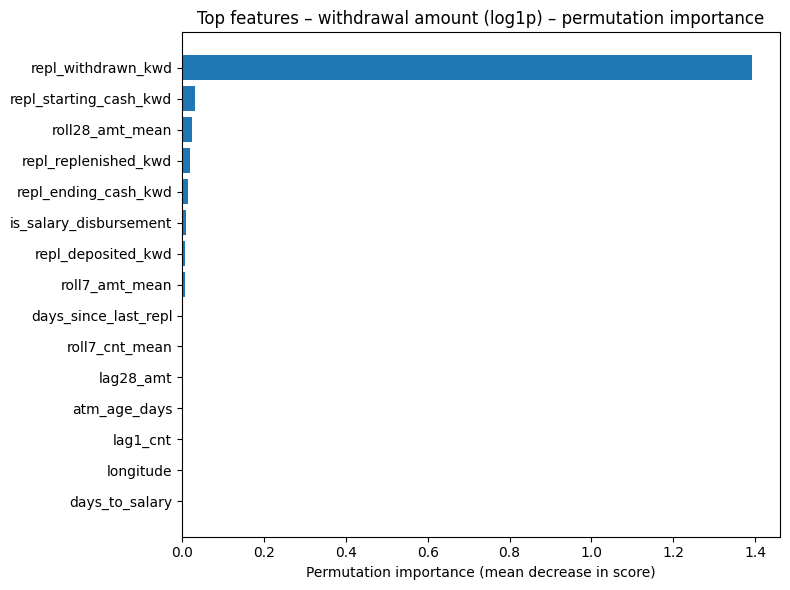

In [17]:
plot_top_features(
    imp_amt,
    title="Top features – withdrawal amount (log1p) – permutation importance",
    filename=OUTPUT_DIR / "perm_importance_amount_top15.png",
    top_n=15,
)

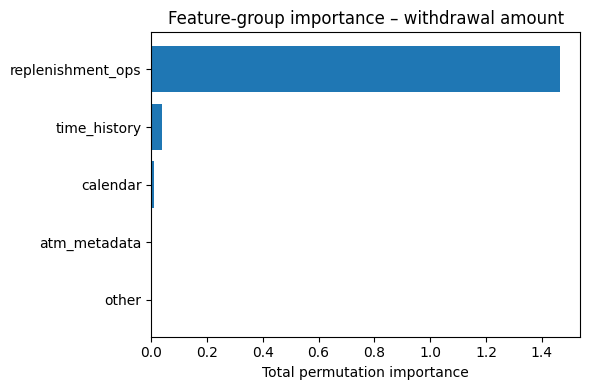

In [18]:
plot_group_importance(
    grp_amt,
    title="Feature-group importance – withdrawal amount",
    filename=OUTPUT_DIR / "perm_importance_amount_groups.png",
)

In [20]:
# permutation importance – withdrawal count (log1p target)

print("Computing permutation importance for WITHDRAW_COUNT (log1p)...")

result_cnt = permutation_importance(
    model_cnt,
    X_val,
    y_val_cnt_log,
    n_repeats=10,
    random_state=42,
    n_jobs=4,
)

imp_cnt = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": result_cnt.importances_mean,
    "importance_std": result_cnt.importances_std,
}).sort_values("importance_mean", ascending=False)

imp_cnt["group"] = imp_cnt["feature"].apply(feature_group)

imp_cnt.to_csv(OUTPUT_DIR / "perm_importance_count_features.csv", index=False)

Computing permutation importance for WITHDRAW_COUNT (log1p)...


In [21]:
grp_cnt = (
    imp_cnt.groupby("group", as_index=False)["importance_mean"]
    .sum()
    .sort_values("importance_mean", ascending=False)
)
grp_cnt.to_csv(OUTPUT_DIR / "perm_importance_count_groups.csv", index=False)

print("Top 10 features for count:")
display(imp_cnt.head(10))
print("Group importance for count:")
display(grp_cnt)

Top 10 features for count:


,feature,importance_mean,importance_std,group
18,repl_withdrawn_kwd,0.884718,0.010450,replenishment_ops
37,roll28_cnt_mean,0.068224,0.002893,time_history
10,location_type_meta,0.063662,0.001810,atm_metadata
2,is_salary_disbursement,0.019646,0.001280,calendar
19,repl_deposited_kwd,0.014527,0.001133,replenishment_ops
35,roll7_cnt_mean,0.007161,0.000411,time_history
20,repl_replenished_kwd,0.004357,0.000532,replenishment_ops
15,location_type_lookup,0.003918,0.000345,atm_metadata
17,repl_starting_cash_kwd,0.003372,0.000307,replenishment_ops
36,roll28_amt_mean,0.002584,0.000151,time_history


Group importance for count:


,group,importance_mean
3,replenishment_ops,0.908287
4,time_history,0.087187
0,atm_metadata,0.069537
1,calendar,0.021651
2,other,0.002489


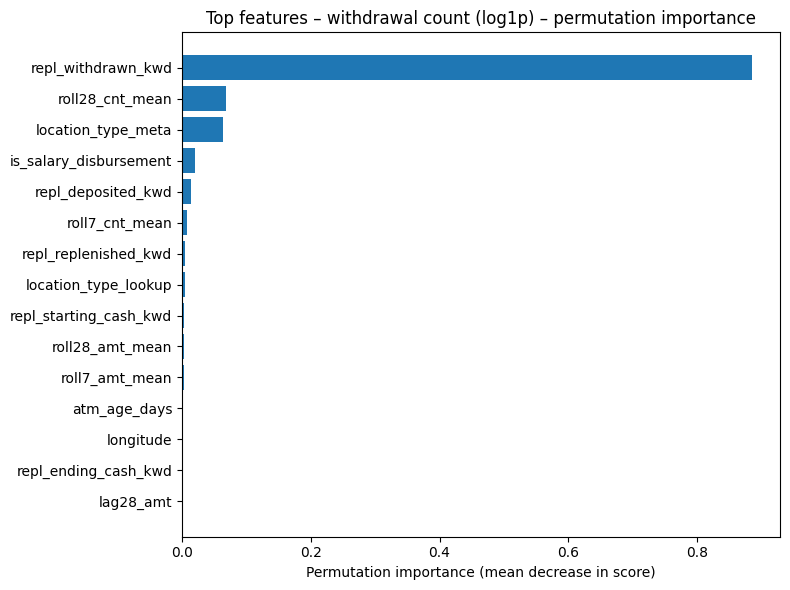

In [22]:
plot_top_features(
    imp_cnt,
    title="Top features – withdrawal count (log1p) – permutation importance",
    filename=OUTPUT_DIR / "perm_importance_count_top15.png",
    top_n=15,
)

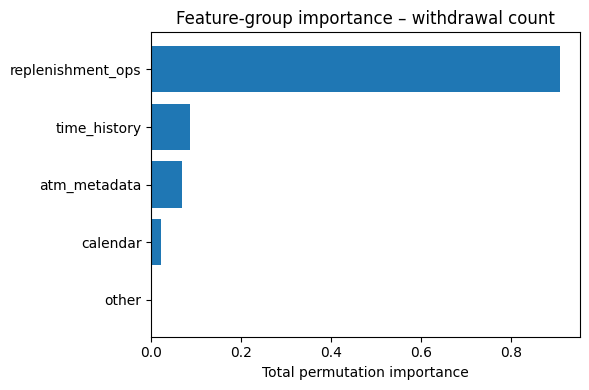

In [23]:
plot_group_importance(
    grp_cnt,
    title="Feature-group importance – withdrawal count",
    filename=OUTPUT_DIR / "perm_importance_count_groups.png",
)

In [ ]:
# recap outputs

print("Files written to:", OUTPUT_DIR.resolve())
list(OUTPUT_DIR.iterdir())